# 🎲 The Bayesian Model, Likelihood & Inference

> **Notebook 04 in the math series.** We have built the two media nonlinearities — *carryover*
> (`math_01`) and *saturation* (`math_02`). Now we wire them, a baseline, and the controls into a
> single **generative probability model**, write down its **likelihood** and **priors** exactly as
> `mmm_framework` does, then **fit** it with NUTS and read off the posterior.

Everything here is grounded in the real model graph in `model/base.py::_build_model`. We will:

1. Recap the full generative model $\mu_t$ and the **Gaussian likelihood** on the *standardized* KPI.
2. Render every **prior** as LaTeX and run a **prior predictive check** — does the prior even put mass
   near the data before it has seen the data?
3. State **Bayes' theorem** for this model and give the **NUTS** intuition (gradient HMC, leapfrog,
   no-U-turn), then **fit** the Aurora model.
4. Check **convergence** ($\hat R$, ESS), inspect the **posterior** (forest of $\beta$, traces),
   produce a **posterior predictive** band against observed sales, **grade ROI** against Aurora's
   known true ROAS, and view the **component decomposition**.
5. Ask the honest meta-question — **did the data actually teach us each parameter?** — with
   *prior-to-posterior* learning diagnostics (contraction / overlap / shift), separating what the
   data pinned from what merely re-states the prior.

As in every math notebook, the code calls the *actual* framework — `BayesianMMM.fit`, `.predict`,
`.summary`, `MMMAnalyzer.compute_channel_roi` — and each plotted quantity is pinned by a seeded
`assert`, so **"the notebook runs clean" means "the inference behaved as the math says it should."**

In [1]:
import warnings, sys
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from aurora import PALETTE, CHANNEL_COLORS   # brand colors for visual consistency
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 4.2),
    "axes.grid": True, "grid.alpha": 0.18,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#cfc7bd", "axes.titleweight": "bold",
    "figure.facecolor": "white", "savefig.facecolor": "white", "font.size": 10,
})
ACCENT, INK, MUTED = PALETTE["accent"], PALETTE["ink"], PALETTE["muted"]

## 1. The generative model — what `_build_model` actually writes

An MMM is a *structured regression*: the KPI is an additive sum of interpretable pieces, with the media
pieces passed through the carryover and saturation transforms of the previous notebooks. Before any of
that, the framework **standardizes** the KPI:

$$
\tilde y_t \;=\; \frac{y_t - \bar y}{s_y},
\qquad \bar y = \tfrac{1}{T}\sum_t y_t,\quad s_y = \operatorname{sd}(y).
$$

The **linear predictor** is built on this standardized scale:

$$
\mu_t \;=\; \underbrace{\text{intercept}}_{\text{base level}}
\;+\; \text{trend}_t \;+\; \text{seasonality}_t
\;+\; \text{geo}_{[g]} \;+\; \text{product}_{[p]}
\;+\; \underbrace{\text{media}_t}_{\text{the part we care about}}
\;+\; \text{controls}_t .
$$

The **media term** sums each channel's saturated, adstocked spend, scaled by a learned coefficient
$\beta_c$:

$$
\text{media}_t \;=\; \sum_{c} \beta_c \, \operatorname{sat}_c\!\Big(\operatorname{adstock}_c\big(x_{c,t}\big)\Big).
$$

The framework's **core saturation** is the *exponential / "logistic"* form (this is the literal code,
`base.py` lines 946–948, **not** a Hill curve — Hill is a documented alternative only):

$$
\operatorname{sat}(u) \;=\; 1 - \exp\!\big(-\lambda\, u\big),
\qquad \lambda = \texttt{sat\_lam}_c > 0,
$$

clipped via $\exp(\operatorname{clip}(-\lambda u, -20, 0))$ for numerical safety. The **default adstock**
(since June 2026) is a *parametric in-graph geometric kernel* with a learned per-channel decay rate:

$$
\operatorname{adstock}_c(x)_t \;=\; \sum_{k=0}^{L-1} w_k\, x_{t-k},
\qquad w_k \propto \alpha_c^{\,k},
\qquad \alpha_c = \texttt{adstock\_alpha\_}c \sim \mathrm{Beta}(1,3).
$$

So $\alpha_c$ **is a real decay rate** the sampler estimates (the legacy path's $m_c$ blend weight —
*not* a decay rate — is the central lesson of `math_01`; it remains available via
`use_parametric_adstock=False`). Controls enter linearly,
$\text{controls}_t = \sum_j \beta^{\text{ctrl}}_j z_{j,t}$.

Finally the **likelihood** — the probability of the data given the parameters — is Gaussian on the
standardized KPI:

$$
\boxed{\;\tilde y_t \;\sim\; \mathcal N\!\big(\mu_t,\ \sigma\big)\;}
\qquad\Longleftrightarrow\qquad
p(\tilde y \mid \theta) \;=\; \prod_{t=1}^{T} \frac{1}{\sigma\sqrt{2\pi}}
\exp\!\left[-\frac{(\tilde y_t - \mu_t)^2}{2\sigma^2}\right].
$$

**Why standardize?** Putting $\tilde y$ on a unit-ish scale ($\bar{\tilde y}=0$, $\operatorname{sd}=1$)
makes a *single set of weakly-informative priors* sensible for **every** dataset: an intercept
$\sim\mathcal N(0,0.5)$ sits near the data mean, $\sigma\sim\text{HalfNormal}(0.5)$ expects residuals on
the order of a fraction of one KPI standard deviation, and the seasonal/trend coefficients live in the
same units. Without standardization those numbers would have to be re-tuned per KPI (sales in dollars
vs. units vs. logits). We will *un-standardize* back to sales for every plot.

Let's load Aurora and build the model object. We keep the demand control in (`control_demand=True`) so
the back-door from the latent demand confounder is at least partly closed — exactly the model a careful
analyst would fit. We keep draws small (300–400) because **PyTensor compilation + NUTS takes a few
minutes**; the *diagnostics*, not raw precision, are the lesson here.

In [2]:
from aurora import generate_aurora, CHANNELS
from mmm_framework import (
    BayesianMMM, ModelConfigBuilder, SeasonalityConfigBuilder, TrendConfig, TrendType,
)

aurora = generate_aurora()
panel = aurora.base_panel(control_demand=True)   # KPI = total sales; Price + CategoryDemand controls

model_config = (
    ModelConfigBuilder()
    .bayesian_pymc()
    .with_chains(2)
    .with_draws(400)
    .with_tune(400)
    .with_seasonality_builder(SeasonalityConfigBuilder().with_yearly(order=2))
    .build()
)
mmm = BayesianMMM(panel, model_config, TrendConfig(type=TrendType.LINEAR))

T = len(aurora.weeks)
print(f"channels   : {mmm.channel_names}")
print(f"controls   : {mmm.control_names}")
print(f"obs (weeks): {T}")
print(f"KPI standardization:  y_mean = {mmm.y_mean:.1f}   y_std = {mmm.y_std:.1f}")

channels   : ['TV', 'Search', 'Social', 'Display']
controls   : ['Price', 'CategoryDemand']
obs (weeks): 104
KPI standardization:  y_mean = 839.0   y_std = 77.0


In [3]:
# VERIFY (1): standardization identity. tilde-y has mean ~0 and sd ~1 by construction,
# and the framework stores the exact (mean, std) it used so we can un-standardize later.
y = aurora.sales_total
y_tilde = (y - mmm.y_mean) / mmm.y_std
assert abs(y_tilde.mean()) < 1e-9,         "standardized KPI should be mean-zero"
assert abs(y_tilde.std() - 1.0) < 1e-9,    "standardized KPI should have unit sd"
# round-trip back to sales is exact
assert np.allclose(y_tilde * mmm.y_std + mmm.y_mean, y, atol=1e-6)
print("✓ standardized KPI:  mean = %.2e   sd = %.6f" % (y_tilde.mean(), y_tilde.std()))
print("✓ un-standardization  tilde_y * y_std + y_mean  recovers sales exactly")

✓ standardized KPI:  mean = 5.34e-16   sd = 1.000000
✓ un-standardization  tilde_y * y_std + y_mean  recovers sales exactly


## 2. The priors — and a prior predictive check

A Bayesian model is the likelihood **times** a prior $p(\theta)$ over every unknown. The framework's
priors are *weakly informative*: loose enough to let the data speak, tight enough to keep the sampler
out of absurd regions and to gently encode domain knowledge (media effects are non-negative; carryover
is bounded; effects are modest on the standardized scale). The exact priors `_build_model` writes:

| Parameter | Symbol | Prior | Role |
|---|---|---|---|
| Intercept | $\text{intercept}$ | $\mathcal N(0,\ 0.5)$ | base level (std. scale) |
| **Channel coefficient** | $\beta_c$ | $\mathrm{Gamma}(\mu{=}1.5,\ \sigma{=}1.0)$ | media effect $\ge 0$ |
| Saturation rate | $\lambda_c=\texttt{sat\_lam}_c$ | $\mathrm{Exponential}(\text{lam}{=}0.5)$ | diminishing-returns speed |
| Adstock **decay** rate | $\alpha_c=\texttt{adstock\_alpha\_}c$ | $\mathrm{Beta}(1,3)$ | carryover per week, prior mean $0.25$ |
| Seasonality coeffs | $\text{season}$ | $\mathcal N(0,\ 0.3)$ | Fourier amplitudes |
| Control coeffs | $\beta^{\text{ctrl}}_j$ | $\mathcal N(0,\ \sigma_{\text{ctrl}})$ | wider for a confounder |
| Geo scale / offset | $\sigma_g,\ u_g$ | $\text{HalfNormal}(0.3),\ \mathcal N(0,1)$ | non-centered: $\sigma_g u_g$ |
| Trend slope | $\text{slope}$ | $\mathcal N(0,\ 0.5)$ | linear drift |
| Noise scale | $\sigma$ | $\text{HalfNormal}(0.5)$ | residual sd (std. scale) |

Two choices deserve a second look. The **$\mathrm{Gamma}(\mu{=}1.5,\sigma{=}1.0)$** on $\beta_c$ is
**positive-only** — it bakes in the prior belief that *more media does not reduce sales* — and places
its mass above zero with a mode around $1$ (an experiment-calibrated prior would replace it; that is
`math_05`). The **$\mathrm{Beta}(1,3)$** on the decay rate is right-skewed with mean $0.25$:
a-priori the model leans toward *short* memory and must be argued into long carryover by the data —
a deliberate, conservative commitment. Let's render the three media priors.

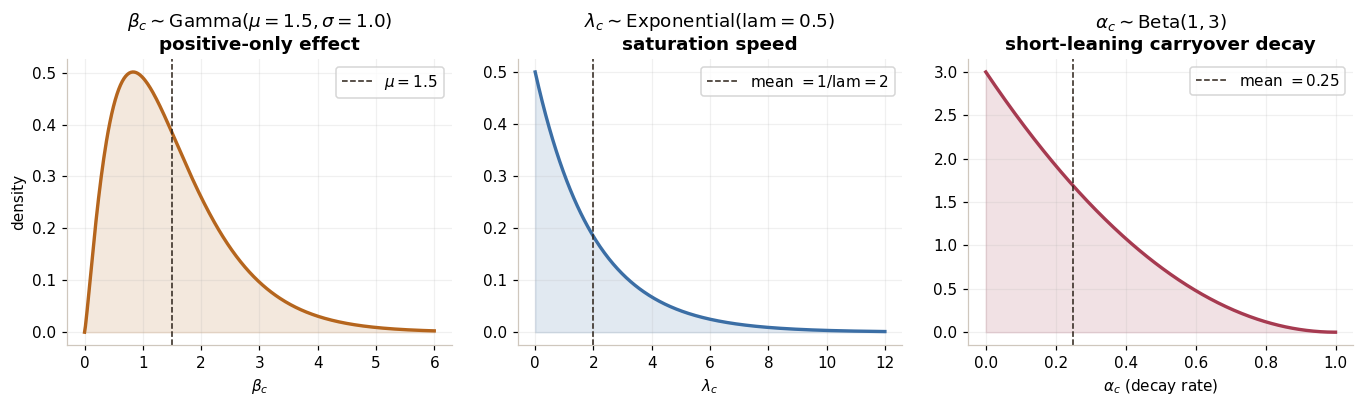

In [4]:
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8))

# beta_c ~ Gamma(mu=1.5, sigma=1.0).  Convert (mu, sigma) -> (shape k, scale theta):
#   mu = k*theta,  sigma^2 = k*theta^2   =>   k = (mu/sigma)^2,  theta = sigma^2/mu
mu_b, sig_b = 1.5, 1.0
k = (mu_b / sig_b) ** 2
theta = sig_b ** 2 / mu_b
bx = np.linspace(0, 6, 400)
axes[0].plot(bx, stats.gamma.pdf(bx, a=k, scale=theta), color=ACCENT, lw=2.2)
axes[0].axvline(mu_b, color=INK, ls="--", lw=1, label=r"$\mu=1.5$")
axes[0].fill_between(bx, stats.gamma.pdf(bx, a=k, scale=theta), color=ACCENT, alpha=0.15)
axes[0].set_title(r"$\beta_c \sim \mathrm{Gamma}(\mu{=}1.5,\sigma{=}1.0)$" + "\npositive-only effect")
axes[0].set_xlabel(r"$\beta_c$"); axes[0].set_ylabel("density"); axes[0].legend()

# sat_lam_c ~ Exponential(lam=0.5)  (rate 0.5 => mean 2)
lx = np.linspace(0, 12, 400)
axes[1].plot(lx, stats.expon.pdf(lx, scale=1 / 0.5), color=PALETTE["sky"], lw=2.2)
axes[1].fill_between(lx, stats.expon.pdf(lx, scale=1 / 0.5), color=PALETTE["sky"], alpha=0.15)
axes[1].axvline(2.0, color=INK, ls="--", lw=1, label=r"mean $=1/\mathrm{lam}=2$")
axes[1].set_title(r"$\lambda_c \sim \mathrm{Exponential}(\mathrm{lam}{=}0.5)$" + "\nsaturation speed")
axes[1].set_xlabel(r"$\lambda_c$"); axes[1].legend()

# adstock decay alpha_c ~ Beta(1,3)
mx = np.linspace(0, 1, 400)
axes[2].plot(mx, stats.beta.pdf(mx, 1, 3), color=PALETTE["berry"], lw=2.2)
axes[2].fill_between(mx, stats.beta.pdf(mx, 1, 3), color=PALETTE["berry"], alpha=0.15)
axes[2].axvline(0.25, color=INK, ls="--", lw=1, label=r"mean $=0.25$")
axes[2].set_title(r"$\alpha_c \sim \mathrm{Beta}(1,3)$" + "\nshort-leaning carryover decay")
axes[2].set_xlabel(r"$\alpha_c$ (decay rate)"); axes[2].legend()

plt.tight_layout(); plt.show()

In [5]:
# VERIFY (2a): the priors are exactly as documented (moments + support).
# Gamma(mu=1.5, sigma=1.0): mean == 1.5 and the reparam k*theta^2 == sigma^2.
assert np.isclose(stats.gamma.mean(a=k, scale=theta), 1.5, atol=1e-9)
assert np.isclose(stats.gamma.std(a=k, scale=theta), 1.0, atol=1e-9)
# beta is positive-only: essentially no mass below 0 (support is (0, inf)).
assert stats.gamma.cdf(0.0, a=k, scale=theta) == 0.0
# Exponential(lam=0.5) has mean 1/0.5 = 2.
assert np.isclose(stats.expon.mean(scale=1 / 0.5), 2.0)
# Beta(1,3) leans short-memory: mean 0.25 with most mass below 0.5.
assert np.isclose(stats.beta.mean(1, 3), 0.25)
assert stats.beta.cdf(0.5, 1, 3) > 0.8
print("✓ Gamma(mu=1.5, sigma=1.0): mean 1.5, sd 1.0, zero mass below 0  (beta_c >= 0)")
print("✓ Exponential(lam=0.5): mean 2.0   |   Beta(1,3): mean 0.25, short-leaning")

✓ Gamma(mu=1.5, sigma=1.0): mean 1.5, sd 1.0, zero mass below 0  (beta_c >= 0)
✓ Exponential(lam=0.5): mean 2.0   |   Beta(1,3): mean 0.25, short-leaning


### Prior predictive check

Before fitting we ask: do these priors, run *forward* through the generative model, produce KPI series
that **look like plausible coffee sales**? This is the **prior predictive distribution**

$$
p(\tilde y^{\text{rep}}) \;=\; \int p(\tilde y^{\text{rep}} \mid \theta)\, p(\theta)\, d\theta,
$$

estimated by sampling $\theta^{(s)}\sim p(\theta)$ and then $\tilde y^{(s)}\sim p(\cdot\mid\theta^{(s)})$.
A good prior predictive *brackets* the observed data range without being absurdly wide. The framework
exposes this as `mmm.sample_prior_predictive(samples=300)`; it stores an original-scale Deterministic
`y_obs_scaled` so we can compare directly to sales.

One subtlety to expect: because the media coefficients are **positive-only** ($\beta_c\sim\mathrm{Gamma}$)
and saturated media only ever *adds*, the prior predictive sits **slightly above** the baseline — the
prior's honest default belief is "media probably helps a bit." So the envelope **leans high** but still
**covers a substantial share** of the observed weeks and contains the data mean — under the
parametric-adstock default (June 2026) the prior is noticeably more concentrated than the legacy
blend's was, so expect bulk-not-blanket coverage. We plot the wide 1–99% band (the
per-week 5–95% band is tighter than the data's full swing, which is fine).

Sampling: [adstock_alpha_Display, adstock_alpha_Search, adstock_alpha_Social, adstock_alpha_TV, beta_Display, beta_Search, beta_Social, beta_TV, beta_controls, intercept, sat_lam_Display, sat_lam_Search, sat_lam_Social, sat_lam_TV, season_yearly, sigma, trend_slope, y_obs]


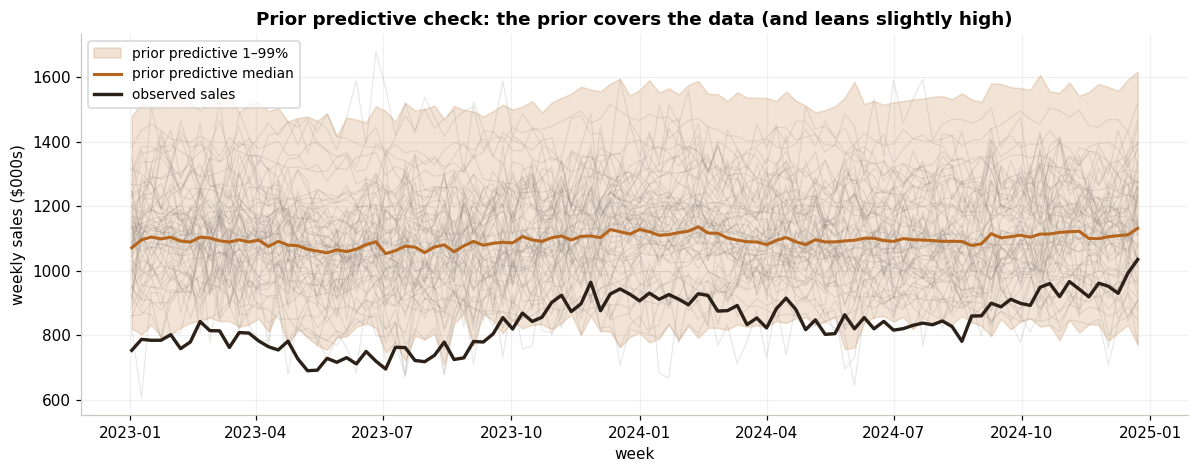

observed sales       range: [690, 1035]  (mean 839)
prior-pred 1–99% env range: [708, 1618]


In [6]:
prior_idata = mmm.sample_prior_predictive(samples=300)

# Original-scale prior predictive KPI draws live in the 'prior' group as 'y_obs_scaled'
# (= y_obs * y_std + y_mean). Flatten (chain, draw) -> samples.
ypp = prior_idata.prior["y_obs_scaled"].values.reshape(-1, T)   # (n_samples, T)
obs = aurora.sales_total

fig, ax = plt.subplots(figsize=(11, 4.4))
# a spaghetti of prior-predictive draws
idx = np.random.default_rng(0).choice(ypp.shape[0], size=60, replace=False)
for j in idx:
    ax.plot(aurora.weeks, ypp[j], color=MUTED, alpha=0.18, lw=0.8)
# prior-predictive 1-99% band (wide: it must bracket the data's full seasonal swing)
lo, hi = np.percentile(ypp, [1, 99], axis=0)
ax.fill_between(aurora.weeks, lo, hi, color=ACCENT, alpha=0.18,
                label="prior predictive 1–99%")
ax.plot(aurora.weeks, np.median(ypp, axis=0), color=ACCENT, lw=2,
        label="prior predictive median")
ax.plot(aurora.weeks, obs, color=INK, lw=2.2, label="observed sales")
ax.set_title("Prior predictive check: the prior covers the data (and leans slightly high)")
ax.set_ylabel("weekly sales ($000s)"); ax.set_xlabel("week")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

print(f"observed sales       range: [{obs.min():.0f}, {obs.max():.0f}]  (mean {obs.mean():.0f})")
print(f"prior-pred 1–99% env range: [{lo.min():.0f}, {hi.max():.0f}]")

In [7]:
# VERIFY (2b): the prior predictive is reasonable -- it puts mass right where the data
# lives. Robust, directional checks (NOT "every week inside the band", and NOT keyed on
# the data's extreme min/max: the prior is right-shifted with a thin lower tail, and
# sample_prior_predictive is unseeded, so extreme-tail brackets are flaky). What IS always
# true: the prior envelope contains the data MEAN, covers a substantial share of weeks,
# and the prior median is the same order of magnitude as the data mean.
# NOTE (June 2026): under the parametric-adstock default the prior predictive is more
# CONCENTRATED than the old blend's (the Beta(1,3) decay prior commits to short memory,
# where the blend smeared mass across the whole fixed-alpha bank), so per-week band
# coverage sits near ~50-60%, down from >70% under the legacy blend. The check is
# correspondingly directional: bulk coverage, not blanket coverage.
band_lo, band_hi = np.percentile(ypp, [1, 99], axis=0)
assert band_lo.min() < obs.mean() < band_hi.max(), "prior envelope should contain the data mean"
frac_inside = np.mean((obs >= band_lo) & (obs <= band_hi))
assert frac_inside > 0.4, f"prior predictive too tight: only {frac_inside:.0%} of weeks covered"
assert 0.5 * obs.mean() < np.median(ypp) < 2.0 * obs.mean(), "prior median wrong order of magnitude"
print(f"✓ prior 1–99% envelope [{band_lo.min():.0f}, {band_hi.max():.0f}] contains data mean {obs.mean():.0f}")
print(f"✓ {frac_inside:.0%} of observed weeks fall inside the prior 1–99% band")
print(f"✓ prior-pred median {np.median(ypp):.0f} is the same order as data mean {obs.mean():.0f}")

✓ prior 1–99% envelope [708, 1618] contains data mean 839
✓ 54% of observed weeks fall inside the prior 1–99% band
✓ prior-pred median 1094 is the same order as data mean 839


## 3. Inference — Bayes' theorem and NUTS

Inference inverts the generative arrow. Given the observed $\tilde y$ we want the **posterior** over
parameters, by **Bayes' theorem**:

$$
\underbrace{p(\theta \mid \tilde y)}_{\text{posterior}}
\;=\;
\frac{\overbrace{p(\tilde y \mid \theta)}^{\text{likelihood}}\;\overbrace{p(\theta)}^{\text{prior}}}
     {\underbrace{p(\tilde y)}_{\text{evidence (a constant in }\theta)}}
\;\;\propto\;\;
p(\tilde y \mid \theta)\, p(\theta).
$$

The denominator $p(\tilde y)=\int p(\tilde y\mid\theta)p(\theta)\,d\theta$ is an intractable integral
over all $\sim\!20$ parameters, so we never compute it. Instead we **sample** from the unnormalized
posterior $p(\tilde y\mid\theta)p(\theta)$, and a histogram of those samples *is* our estimate of the
posterior — every credible interval, every ROI band below comes from these draws.

### NUTS in one paragraph

The sampler is the **No-U-Turn Sampler**, an adaptive form of **Hamiltonian Monte Carlo**. HMC treats
$-\log\big[p(\tilde y\mid\theta)p(\theta)\big]$ as a *potential energy* surface and the current
parameter as a particle. It draws a random *momentum*, then rolls the particle along the surface using
**leapfrog integration** — discrete steps that alternate gradient kicks to the momentum and drifts of
the position:

$$
p \leftarrow p - \tfrac{\epsilon}{2}\nabla U(\theta),\quad
\theta \leftarrow \theta + \epsilon\, p,\quad
p \leftarrow p - \tfrac{\epsilon}{2}\nabla U(\theta).
$$

Because the proposal *follows the gradient* of the log-posterior, it glides along high-probability
ridges instead of random-walking, so it explores correlated, high-dimensional posteriors efficiently.
**NUTS** removes the one hard tuning knob (the number of leapfrog steps): it keeps integrating until the
trajectory starts to curve back on itself — a **"U-turn"** — then stops, which is why it needs the
model to be **differentiable** (the in-graph PyTensor transforms from `math_01`/`math_02` provide
$\nabla U$). The result is a set of approximately-independent draws from the posterior.

Now we fit. **On macOS `cores=1` is required** or the sampler crashes. We seed for reproducibility.

In [8]:
# FIT. PyTensor compile + 2 chains x (400 tune + 400 draws) -> a few minutes.
# cores=1 is REQUIRED on macOS.
results = mmm.fit(draws=400, tune=400, chains=2, cores=1, random_seed=0)
print("sampling complete.")
print(f"divergences : {results.diagnostics['divergences']}")
print(f"max r_hat   : {results.diagnostics['rhat_max']:.4f}")
print(f"min ess_bulk: {results.diagnostics['ess_bulk_min']:.0f}")

Sampling: [adstock_alpha_Display, adstock_alpha_Search, adstock_alpha_Social, adstock_alpha_TV, beta_Display, beta_Search, beta_Social, beta_TV, beta_controls, intercept, sat_lam_Display, sat_lam_Search, sat_lam_Social, sat_lam_TV, season_yearly, sigma, trend_slope, y_obs]


Initializing NUTS using adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [intercept, trend_slope, season_yearly, adstock_alpha_TV, sat_lam_TV, beta_TV, adstock_alpha_Search, sat_lam_Search, beta_Search, adstock_alpha_Social, sat_lam_Social, beta_Social, adstock_alpha_Display, sat_lam_Display, beta_Display, beta_controls, sigma]


Output()

Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 21 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


sampling complete.
divergences : 0
max r_hat   : 1.0113
min ess_bulk: 152


## 4. Convergence diagnostics — did the sampler work?

MCMC only gives the *right* posterior if the chains **mixed**. Two standard checks:

**$\hat R$ (R-hat, Gelman–Rubin).** Run several chains from different starts. $\hat R$ compares the
*between-chain* variance to the *within-chain* variance of each parameter:

$$
\hat R \;\approx\; \sqrt{\frac{\widehat{\operatorname{Var}}^{+}(\theta)}{W}},
\qquad
\widehat{\operatorname{Var}}^{+} = \frac{N-1}{N}\,W + \frac{1}{N}\,B,
$$

with $W$ the within-chain and $B$ the between-chain variance. If the chains have converged to the same
distribution, $B$ and $W$ agree and $\hat R \to 1$. The rule of thumb: **$\hat R < 1.01$** is great,
$> 1.1$ is a red flag (chains disagree — do not trust the posterior).

**ESS (effective sample size).** Successive MCMC draws are *autocorrelated*, so $N$ draws are worth
*fewer* than $N$ independent ones. ESS estimates that effective count,
$\text{ESS} \approx N / \big(1 + 2\sum_{k\ge1}\rho_k\big)$ where $\rho_k$ is the lag-$k$ autocorrelation.
A few hundred is usually enough for stable means and intervals. `mmm.summary(...)` returns both, in an
ArviZ table.

In [9]:
import pandas as pd
beta_vars = [f"beta_{ch}" for ch in mmm.channel_names]
satl_vars = [f"sat_lam_{ch}" for ch in mmm.channel_names]
ad_vars   = [f"adstock_alpha_{ch}" for ch in mmm.channel_names]
key_vars  = beta_vars + satl_vars + ad_vars + ["intercept", "sigma"]

summ = mmm.summary(var_names=key_vars)
cols = [col for col in ["mean", "sd", "hdi_3%", "hdi_97%", "r_hat", "ess_bulk"] if col in summ.columns]
summ_show = summ[cols].round(3)
summ_show

,mean,sd,hdi_3%,hdi_97%,r_hat,ess_bulk
beta_TV,1.064,0.822,0.029,2.509,1.00,652.0
beta_Search,1.623,1.090,0.043,3.470,1.00,205.0
beta_Social,1.268,0.981,0.060,3.139,1.00,445.0
beta_Display,1.043,0.828,0.020,2.511,1.00,565.0
sat_lam_TV,0.630,0.904,0.001,1.913,1.00,640.0
sat_lam_Search,0.727,0.739,0.002,1.630,1.00,378.0
sat_lam_Social,0.638,0.808,0.001,1.862,1.00,574.0
sat_lam_Display,0.665,0.977,0.000,2.318,1.00,487.0
adstock_alpha_TV,0.386,0.260,0.007,0.837,1.00,514.0
adstock_alpha_Search,0.553,0.270,0.066,0.942,1.00,196.0


In [10]:
# VERIFY (4): convergence. All r_hat < 1.1 (the textbook red-line), seeded fit.
rhat = summ["r_hat"].to_numpy()
assert np.all(rhat < 1.1), f"non-converged params: max r_hat = {rhat.max():.3f}"
assert np.all(summ["ess_bulk"] > 50), "effective sample size suspiciously low"
print(f"✓ all {len(rhat)} key parameters have r_hat < 1.1   (max = {rhat.max():.3f})")
print(f"✓ all ess_bulk > 50   (min = {summ['ess_bulk'].min():.0f})")

✓ all 14 key parameters have r_hat < 1.1   (max = 1.010)
✓ all ess_bulk > 50   (min = 196)


A picture makes $\hat R$ concrete: plot every parameter's $\hat R$ against the $1.1$ red-line and the
$1.01$ "great" line. All bars should hug $1$.

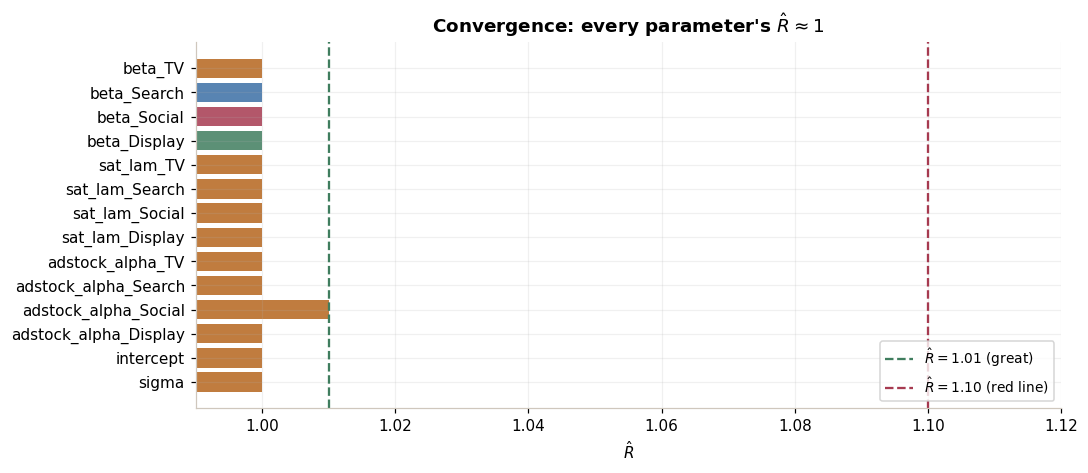

In [11]:
fig, ax = plt.subplots(figsize=(10, 4.4))
names = list(summ.index)
rh = summ["r_hat"].to_numpy()
colors = [CHANNEL_COLORS.get(n.split("_", 1)[-1], ACCENT) for n in names]
ax.barh(names, rh, color=colors, alpha=0.85)
ax.axvline(1.01, color=PALETTE["leaf"], ls="--", lw=1.5, label=r"$\hat R = 1.01$ (great)")
ax.axvline(1.10, color=PALETTE["berry"], ls="--", lw=1.5, label=r"$\hat R = 1.10$ (red line)")
ax.set_xlim(0.99, max(1.12, rh.max() + 0.01))
ax.set_xlabel(r"$\hat R$"); ax.set_title(r"Convergence: every parameter's $\hat R \approx 1$")
ax.legend(loc="lower right", fontsize=9)
ax.invert_yaxis()
plt.tight_layout(); plt.show()

And a **trace plot** for one or two parameters: the left panel overlays each chain's marginal density
(they should *coincide*), the right shows the sampled value vs. iteration (a "fuzzy caterpillar" with
no trends or stuck chains = good mixing). We locate the posterior `InferenceData` on the model instance
at `mmm._trace`.

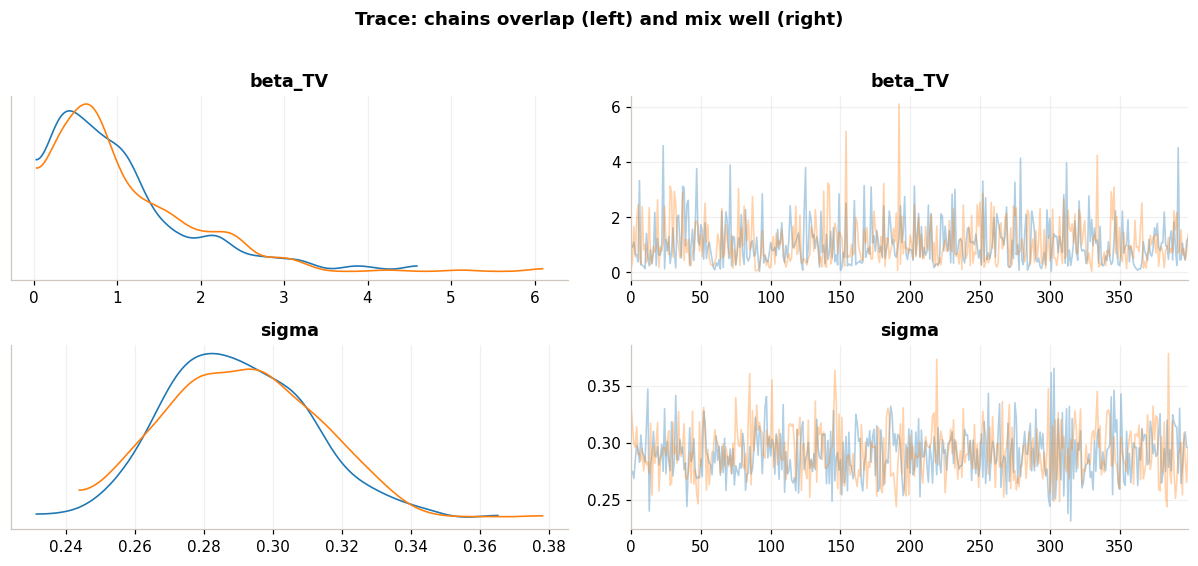

trace InferenceData located at mmm._trace; posterior groups: ['posterior', 'sample_stats', 'prior', 'prior_predictive', 'observed_data', 'constant_data']


In [12]:
import arviz as az
idata = mmm._trace          # the posterior InferenceData produced by fit()
assert "posterior" in idata.groups(), "expected a posterior group on mmm._trace"

az.plot_trace(idata, var_names=["beta_TV", "sigma"], compact=False,
              figsize=(11, 5))
plt.suptitle("Trace: chains overlap (left) and mix well (right)", y=1.02, fontweight="bold")
plt.tight_layout(); plt.show()
print("trace InferenceData located at mmm._trace; posterior groups:", list(idata.groups()))

## 5. Posterior inference — what did we learn about each channel?

The posterior is a *distribution*, not a point. The natural summary is a **forest plot**: each
parameter's posterior mean with a **credible interval** (here the 94% highest-density interval, the
ArviZ default). For the channel coefficients $\beta_c$ — the media effect sizes — this shows both *how
big* each effect is and *how sure* we are.

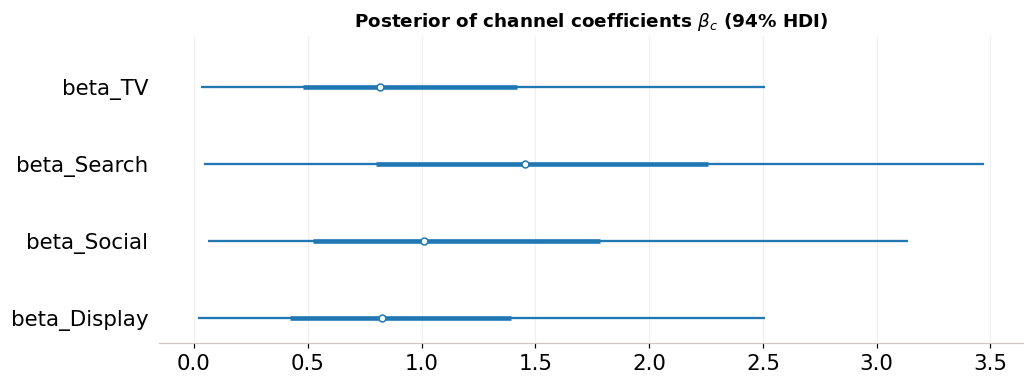

In [13]:
fig, ax = plt.subplots(figsize=(9.5, 3.6))
az.plot_forest(idata, var_names=beta_vars, combined=True, hdi_prob=0.94, ax=ax)
ax.set_title(r"Posterior of channel coefficients $\beta_c$ (94% HDI)")
plt.tight_layout(); plt.show()

In [14]:
# VERIFY (5a): every channel's POSTERIOR MEAN beta is positive. The Gamma prior makes
# beta_c >= 0 by construction, but a directional check confirms the data did not fight it.
post = idata.posterior
beta_means = {ch: float(post[f"beta_{ch}"].mean()) for ch in mmm.channel_names}
for ch, bm in beta_means.items():
    assert bm > 0, f"posterior mean beta_{ch} not positive: {bm}"
print("✓ all posterior-mean channel betas > 0:")
for ch, bm in beta_means.items():
    print(f"    beta_{ch:<8} = {bm:6.3f}")

✓ all posterior-mean channel betas > 0:
    beta_TV       =  1.064
    beta_Search   =  1.623
    beta_Social   =  1.268
    beta_Display  =  1.043


The saturation rates $\lambda_c$ are estimated jointly with $\beta_c$. Recall from `math_01` that
$\lambda$ and $\beta$ partly *trade off* (equifinality): a forest of $\lambda_c$ shows how tightly each
is pinned. Wide intervals here are a feature, not a bug — they are the model **honestly reporting** that
observational data alone weakly identifies the saturation speed.

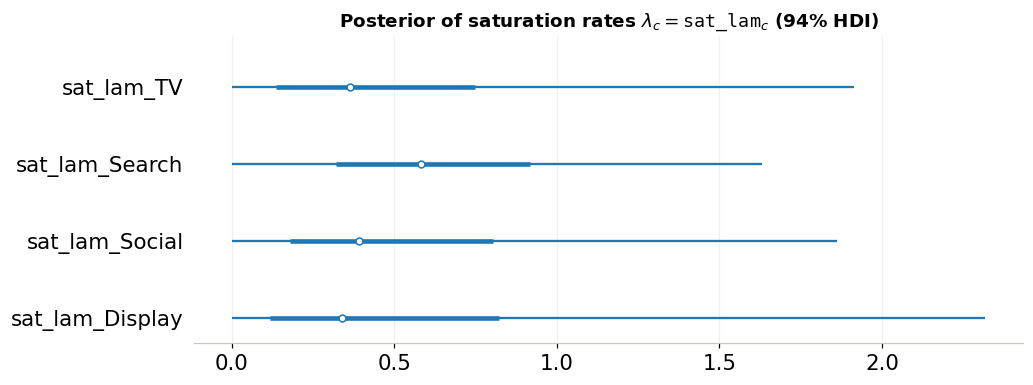

In [15]:
fig, ax = plt.subplots(figsize=(9.5, 3.6))
az.plot_forest(idata, var_names=satl_vars, combined=True, hdi_prob=0.94, ax=ax)
ax.set_title(r"Posterior of saturation rates $\lambda_c = \mathtt{sat\_lam}_c$ (94% HDI)")
plt.tight_layout(); plt.show()

### ROI with uncertainty — and grading against the truth

The thing decision-makers actually want is **return on ad spend (ROAS)**: incremental sales per dollar.
`MMMAnalyzer.compute_channel_roi()` propagates the *full posterior* through a counterfactual
(zero-out-the-channel) contribution calculation, so every channel gets a **Contribution HDI** — which,
divided by total spend, becomes a **ROAS band**. (Note: this call has no `hdi_prob` argument; it
defaults to a 94% HDI.)

Because Aurora is synthetic, we know the **true** total-effect ROAS of every channel
(`aurora.true_roas`) and can *grade* the model. Spoiler from the dataset design: TV and Display work
mostly through an **awareness mediator** this single-equation model cannot see, and Search/Social spend
**chases latent demand**. So we *expect* bias — recovering the truth needs either a mediation model
(`03_extended`) or experiment calibration (`math_05`). This plot is the honest "before" picture.

In [16]:
from mmm_framework.analysis import MMMAnalyzer

roi = MMMAnalyzer(mmm).compute_channel_roi()    # DataFrame; 94% HDI by default
roi = roi.set_index("Channel").loc[mmm.channel_names]
# ROAS band = absolute Contribution HDI / Total Spend.
roi["ROAS_low"]  = roi["Contribution HDI Low"]  / roi["Total Spend"]
roi["ROAS_high"] = roi["Contribution HDI High"] / roi["Total Spend"]
roi[["Total Spend", "Total Contribution", "ROI", "ROAS_low", "ROAS_high"]].round(3)

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

Sampling: [y_obs]


...

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

,Total Spend,Total Contribution,ROI,ROAS_low,ROAS_high
Channel,,,,,
TV,6053.775,2033.734,0.336,-0.007,1.081
Search,3312.382,3443.837,1.040,-0.009,2.718
Social,3095.751,2193.304,0.708,-0.002,2.382
Display,2853.729,1919.914,0.673,-0.085,2.510


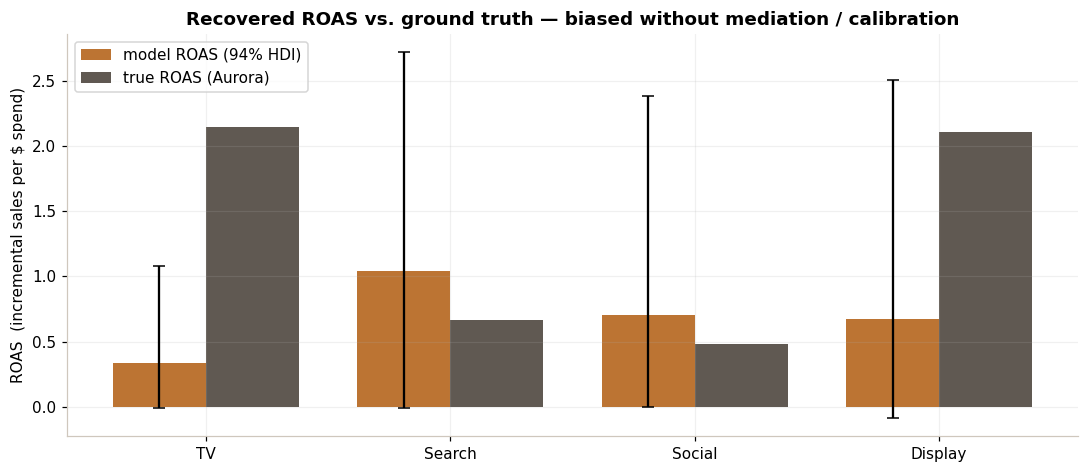

channel   model_ROI   true_ROAS
  TV          0.336      2.143
  Search      1.040      0.664
  Social      0.708      0.486
  Display     0.673      2.111


In [17]:
chs = mmm.channel_names
xpos = np.arange(len(chs))
width = 0.38

model_roi = roi["ROI"].to_numpy()
roi_lo = roi["ROAS_low"].to_numpy()
roi_hi = roi["ROAS_high"].to_numpy()
true_roas = aurora.true_roas.loc[chs].to_numpy()

# asymmetric error bars from the absolute-contribution HDI
err_low = np.clip(model_roi - roi_lo, 0, None)
err_high = np.clip(roi_hi - model_roi, 0, None)

fig, ax = plt.subplots(figsize=(10, 4.4))
ax.bar(xpos - width / 2, model_roi, width, color=ACCENT, alpha=0.9,
       yerr=[err_low, err_high], capsize=4, label="model ROAS (94% HDI)")
ax.bar(xpos + width / 2, true_roas, width, color=INK, alpha=0.75, label="true ROAS (Aurora)")
ax.set_xticks(xpos); ax.set_xticklabels(chs)
ax.set_ylabel("ROAS  (incremental sales per $ spend)")
ax.set_title("Recovered ROAS vs. ground truth — biased without mediation / calibration")
ax.legend()
plt.tight_layout(); plt.show()

print("channel   model_ROI   true_ROAS")
for ch, m, t in zip(chs, model_roi, true_roas):
    print(f"  {ch:<8} {m:8.3f}   {t:8.3f}")

In [18]:
# VERIFY (5b): the ROI table is well-formed and the HDI band brackets the point ROI.
assert set(["Total Spend", "Total Contribution", "ROI",
            "Contribution HDI Low", "Contribution HDI High"]).issubset(roi.columns)
assert np.all(roi_lo <= model_roi + 1e-9) and np.all(model_roi <= roi_hi + 1e-9), \
    "point ROI should sit inside its own ROAS HDI band"
assert np.all(model_roi > 0), "all channel point-ROIs should be positive here"
print("✓ ROI table has the documented columns; point ROI lies within its 94% ROAS band")
print("✓ all channel ROIs > 0 (as the positive-beta prior guarantees)")

✓ ROI table has the documented columns; point ROI lies within its 94% ROAS band
✓ all channel ROIs > 0 (as the positive-beta prior guarantees)


## 6. Posterior predictive check — does the fitted model reproduce the data?

The **posterior predictive** replays the generative model *forward* using the **fitted** posterior:

$$
p(\tilde y^{\text{rep}} \mid \tilde y) \;=\; \int p(\tilde y^{\text{rep}}\mid\theta)\,
p(\theta \mid \tilde y)\, d\theta .
$$

`mmm.predict(return_original_scale=True, hdi_prob=0.9)` returns the mean prediction and a 90% HDI band
(on the sales scale). A well-fit model tracks the observed series and keeps **most** weeks inside the
band — the band's width is the model's honest forecast uncertainty.

Sampling: [y_obs]


Output()

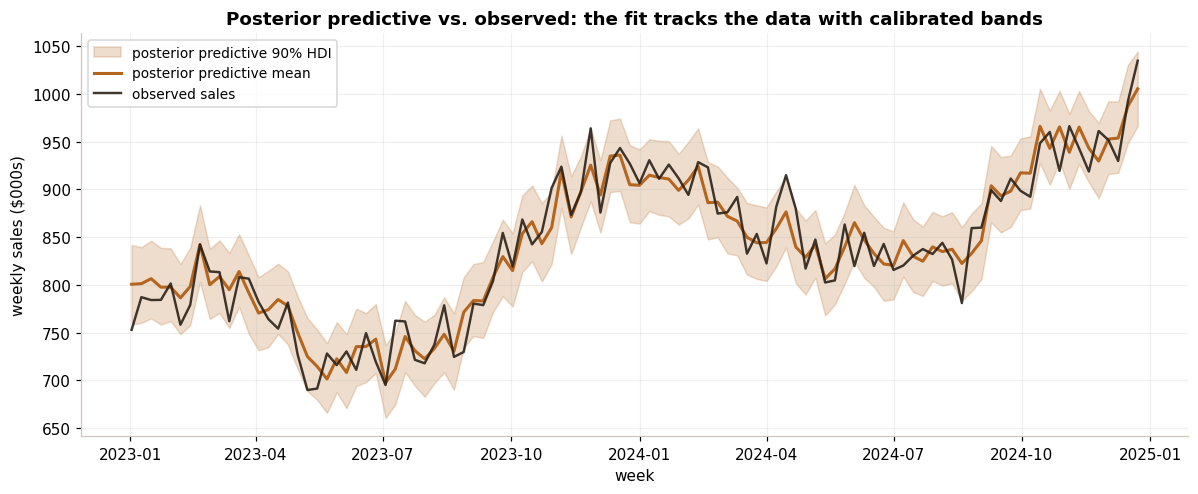

In [19]:
pred = mmm.predict(return_original_scale=True, hdi_prob=0.9)

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.fill_between(aurora.weeks, pred.y_pred_hdi_low, pred.y_pred_hdi_high,
                color=ACCENT, alpha=0.22, label="posterior predictive 90% HDI")
ax.plot(aurora.weeks, pred.y_pred_mean, color=ACCENT, lw=2, label="posterior predictive mean")
ax.plot(aurora.weeks, aurora.sales_total, color=INK, lw=1.6, alpha=0.9, label="observed sales")
ax.set_title("Posterior predictive vs. observed: the fit tracks the data with calibrated bands")
ax.set_ylabel("weekly sales ($000s)"); ax.set_xlabel("week")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

In [20]:
# VERIFY (6): the fit is genuinely good. Correlation of predicted vs observed > 0.7,
# and most weeks fall inside the 90% predictive band. Seeded, directional.
obs = aurora.sales_total
corr = np.corrcoef(pred.y_pred_mean, obs)[0, 1]
assert corr > 0.7, f"predicted vs observed correlation too low: {corr:.3f}"
inside = np.mean((obs >= pred.y_pred_hdi_low) & (obs <= pred.y_pred_hdi_high))
assert inside > 0.6, f"too few weeks inside the 90% band: {inside:.0%}"
r2 = 1 - np.sum((obs - pred.y_pred_mean) ** 2) / np.sum((obs - obs.mean()) ** 2)
print(f"✓ corr(predicted, observed) = {corr:.3f}  (> 0.7)")
print(f"✓ {inside:.0%} of weeks inside the 90% predictive band")
print(f"  (in-sample R^2 = {r2:.3f})")

✓ corr(predicted, observed) = 0.962  (> 0.7)
✓ 91% of weeks inside the 90% predictive band
  (in-sample R^2 = 0.925)


## 7. Component decomposition — where do the sales come from?

The additive structure lets us split fitted sales into **baseline + per-channel media**, using the
posterior mean of each term. On the standardized scale

$$
\tilde\mu_t \;=\; \underbrace{\text{intercept}}_{\text{level}}
\;+\; \text{trend}_t + \text{season}_t
\;+\; \underbrace{\textstyle\sum_j \gamma_j\, z_{j,t}}_{\text{controls}}
\;+\; \sum_c \beta_c\,\operatorname{sat}_c\!\big(\operatorname{adstock}_c(x_c)\big)_t ,
$$

and multiplying back by $y_{\text{std}}$ — with the standardization offset $\bar y$ folded into the
intercept — puts every piece in original sales units:

$$
\hat\mu_t \;=\; \tilde\mu_t\, y_{\text{std}} + \bar y
\;=\; \underbrace{\big(\text{intercept}_t + \text{trend}_t + \text{season}_t + \text{controls}_t\big)}_{\text{baseline}_t}
\;+\; \sum_c \text{media}_{c,t}.
$$

`mmm.compute_component_decomposition()` returns exactly these pieces on the **original sales scale**,
already un-standardized, as fields on the returned `dec` object:
`dec.intercept` (the real posterior intercept, per obs, with $\bar y$ folded in), `dec.trend`,
`dec.seasonality`, `dec.controls_total` (per obs), and `dec.media_by_channel` (a DataFrame, one column
per channel). Because the framework emits a Deterministic for *every* term in $\tilde\mu_t$, the helper
is **additive and complete**: summing the baseline pieces and the per-channel media reproduces the fitted
line. We verify $\operatorname{corr}\!\big(\text{baseline}+\sum_c\text{media}_c,\ \widehat{y}\big) > 0.99$
below.

The **upper panel** stacks per-channel media on the **baseline** band. The baseline folds the *mean-zero*
seasonality and control swings into the intercept level, so each layer stays non-negative and the stack
**top tracks `predict()`** (dashed) — additivity made visible. The **lower panel** isolates the **controls**
term: Aurora has two genuine controls — **Price** and **CategoryDemand** — that move sales by real amounts
week to week, and `dec.controls_total` now captures them correctly. Note that centered controls and Fourier
seasonality are *mean-zero by construction* (they lift sales in cold / under-priced weeks and lower them
otherwise), so they carry real **amplitude** even though they average out of the *level* — which is exactly
why media, the small incremental slice, rides on a large organic **baseline**.

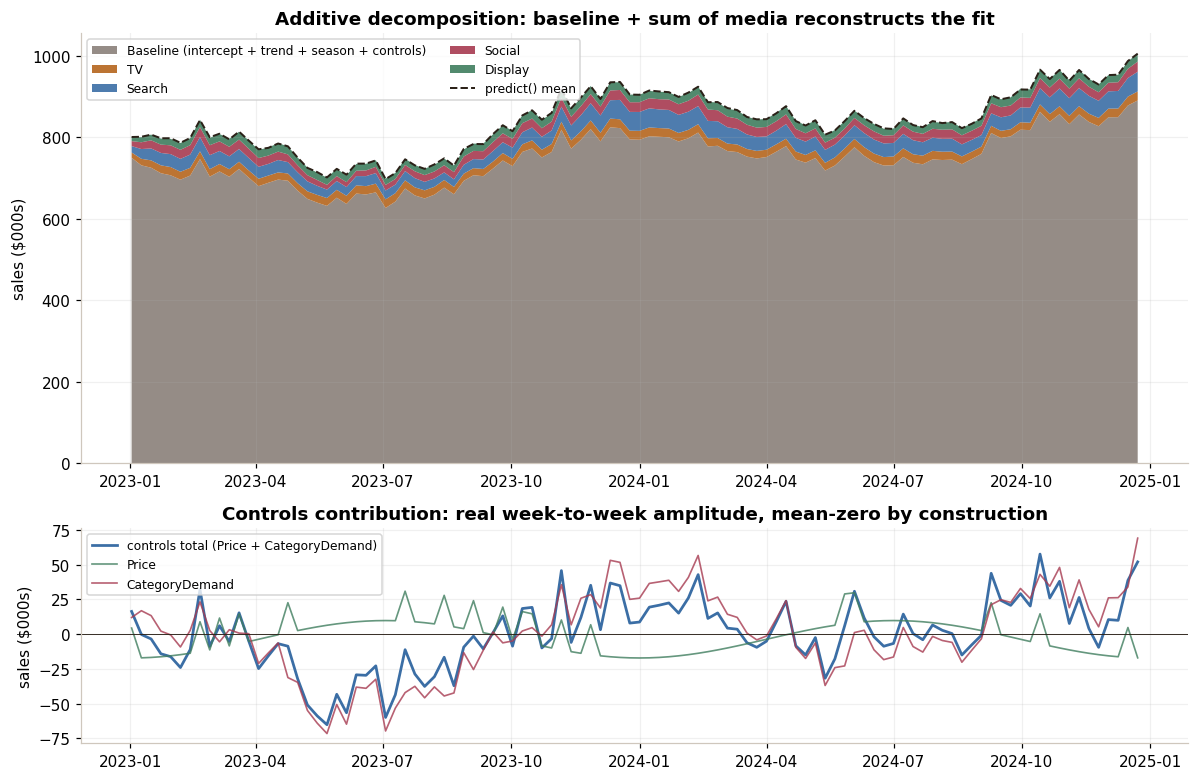

component contribution ($000s/wk) -- mean (level) and std (amplitude):
  Baseline     mean    747.4   std    61.4
  Seasonality  mean     -0.0   std    27.0
  Controls     mean     -0.0   std    24.8
  TV           mean     19.4
  Search       mean     33.1
  Social       mean     21.1
  Display      mean     18.4


In [21]:
# The FIXED framework helper: every term in mu_t is emitted as a Deterministic, so this
# is additive and complete. All fields are already on the original sales scale.
dec = mmm.compute_component_decomposition()

# Baseline absorbs the mean-zero seasonality + centered controls into the intercept level.
baseline_t = dec.intercept + dec.trend + dec.seasonality + dec.controls_total   # (T,)
media_sum  = dec.media_by_channel.sum(axis=1).values                            # (T,)
recon_fit  = baseline_t + media_sum                                             # additive
pred_mean  = pred.y_pred_mean                  # reuse the posterior-predictive mean from §6
media_means = {ch: float(dec.media_by_channel[ch].mean()) for ch in mmm.channel_names}

idx = mmm.panel.index
fig, (axA, axB) = plt.subplots(2, 1, figsize=(11, 7.2),
                               gridspec_kw={"height_ratios": [2.0, 1.0]})

# Panel A: additive stacked-area decomposition (baseline + stacked media) tracks the fit.
stack = [baseline_t] + [dec.media_by_channel[ch].values for ch in mmm.channel_names]
axA.stackplot(idx, *stack,
              labels=["Baseline (intercept + trend + season + controls)"] + list(mmm.channel_names),
              colors=[MUTED] + [CHANNEL_COLORS[ch] for ch in mmm.channel_names], alpha=0.9)
axA.plot(idx, pred_mean, color=INK, lw=1.3, ls="--", label="predict() mean")
axA.set_title("Additive decomposition: baseline + sum of media reconstructs the fit")
axA.set_ylabel("sales ($000s)"); axA.legend(loc="upper left", ncol=2, fontsize=8)

# Panel B: the controls term -- now correctly non-zero (Price + CategoryDemand).
axB.plot(idx, dec.controls_total, color=PALETTE["sky"], lw=1.8,
         label="controls total (Price + CategoryDemand)")
if dec.controls_by_var is not None:
    for var, col in zip(dec.controls_by_var.columns, [PALETTE["leaf"], PALETTE["berry"]]):
        axB.plot(idx, dec.controls_by_var[var].values, color=col, lw=1.1, alpha=0.8, label=var)
axB.axhline(0, color=INK, lw=0.6)
axB.set_title("Controls contribution: real week-to-week amplitude, mean-zero by construction")
axB.set_ylabel("sales ($000s)"); axB.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

print("component contribution ($000s/wk) -- mean (level) and std (amplitude):")
print(f"  {'Baseline':<12} mean {np.mean(baseline_t):8.1f}   std {np.std(baseline_t):7.1f}")
print(f"  {'Seasonality':<12} mean {np.mean(dec.seasonality):8.1f}   std {np.std(dec.seasonality):7.1f}")
print(f"  {'Controls':<12} mean {np.mean(dec.controls_total):8.1f}   std {np.std(dec.controls_total):7.1f}")
for ch in mmm.channel_names:
    print(f"  {ch:<12} mean {media_means[ch]:8.1f}")

In [22]:
# VERIFY (7): the framework decomposition is additive and complete -- baseline + sum of
# media reconstructs predict(); media columns are exactly the channels; the controls term
# carries real week-to-week amplitude (Aurora has Price + CategoryDemand); and the organic
# baseline dwarfs the small incremental media slice. Directional, seeded fit.
r = float(np.corrcoef(recon_fit, pred_mean)[0, 1])
total_media_mean = float(media_sum.mean())
assert r > 0.99, f"baseline + media should track the fit; corr={r:.3f}"
assert list(dec.media_by_channel.columns) == list(mmm.channel_names), \
    "media_by_channel columns must be the channel names"
assert np.std(dec.controls_total) > 1.0, \
    "controls_total must carry real week-to-week amplitude (Price + CategoryDemand)"
assert np.mean(baseline_t) > total_media_mean, "organic baseline should dwarf total media"
print(f"✓ framework decomposition is additive: corr(baseline + sum media, predict) = {r:.4f}")
print(f"✓ media_by_channel columns == channel names: {list(dec.media_by_channel.columns)}")
print(f"✓ controls_total carries real amplitude: std = {np.std(dec.controls_total):.1f} "
      f"$000s/wk (Price + CategoryDemand), mean = {np.mean(dec.controls_total):.1f} (~mean-zero)")
print(f"✓ organic baseline (mean {np.mean(baseline_t):.0f}) >> total mean media ({total_media_mean:.0f})")

✓ framework decomposition is additive: corr(baseline + sum media, predict) = 0.9999
✓ media_by_channel columns == channel names: ['TV', 'Search', 'Social', 'Display']
✓ controls_total carries real amplitude: std = 24.8 $000s/wk (Price + CategoryDemand), mean = -0.0 (~mean-zero)
✓ organic baseline (mean 747) >> total mean media (92)


## 8. Did the data actually teach us each parameter? — prior-to-posterior learning

Every plot above read the **posterior**. But a posterior credible interval only tells you what you
believe *after* seeing the data — it does **not** tell you how much of that belief came from the **data**
versus the **prior**. A tight, confident-looking posterior can be a faithful echo of an informative
prior, not a discovery.

The sharpest version of this trap is a **sign-constrained prior**. The cannibalization cross-effect in
the framework's `MultivariateMMM` has prior $\psi = -\mathrm{HalfNormal}(\sigma)$ — *structurally*
$\psi \le 0$. Reporting that "the posterior of $\psi$ is entirely below zero", i.e.
$P(\psi < 0) \approx 1$, is then nearly **vacuous**: so is the prior, by construction. The statement
restates the prior and pretends it is a finding.

> **A one-sided / informative prior makes a sign statement like $P(\psi < 0)\approx 1$ nearly vacuous —
> it can just restate the prior. The honest replacement is *contraction* / *overlap*: how much did the
> data move and narrow the parameter beyond the prior?**

The framework answers that with `model.compute_parameter_learning(...)`, which compares prior samples to
the fitted posterior with three complementary, sample-based diagnostics (Betancourt; Schad, Betancourt &
Vasishth 2021):

$$
\underbrace{c \;=\; 1 - \frac{\mathrm{Var}_{\text{post}}}{\mathrm{Var}_{\text{prior}}}}_{\textbf{contraction}}
\qquad
\underbrace{\mathrm{OVL} \;=\; \sum_i \min\!\big(p_i,\, q_i\big)}_{\textbf{overlap (shared bins)}}
\qquad
\underbrace{z \;=\; \frac{\bar\theta_{\text{post}} - \bar\theta_{\text{prior}}}{\mathrm{sd}_{\text{prior}}}}_{\textbf{shift\_z}}
$$

* **Contraction** $c$ is a pure variance ratio. $c \to 1$ means the posterior is far narrower than the
  prior — *the data pinned it*; $c \approx 0$ means the posterior is as wide as the prior — *data
  uninformative, prior-dominated*; $c < 0$ means the posterior is **wider** than the prior — a red flag
  for **prior-data conflict** or poor sampling (the framework deliberately does **not** clip it).
* **Overlap** $\mathrm{OVL} \in [0,1]$ is the prior-posterior overlap coefficient over shared histogram
  bins ($p_i, q_i$ are the prior/posterior probability masses in bin $i$). $\mathrm{OVL} \approx 1$:
  posterior indistinguishable from prior (nothing learned); $\mathrm{OVL} \approx 0$: strong learning.
  Histogram bins — not a Gaussian KDE — so a hard prior edge (e.g. the $\mathrm{HalfNormal}$ boundary at
  $0$) is **not** smeared.
* **shift_z** catches pure *location* learning that contraction alone misses: a posterior can shift far
  without narrowing.

A heuristic `verdict` column then labels each parameter **strong** / **moderate** / **weak** /
**prior-dominated** from $c$ and $\mathrm{OVL}$ (the thresholds are conventions, not law). The frame is
sorted by contraction **ascending**, so the *least-learned, most prior-dominated* parameters sort to the
**top** — exactly where you want your eye to land.

In [23]:
from mmm_framework.diagnostics import plot_parameter_learning, plot_prior_posterior_overlay

# Compare 2000 prior draws to the fitted posterior, for every free RV of the model.
lrn = mmm.compute_parameter_learning(prior_samples=2000)
lrn.round(3)

Sampling: [adstock_alpha_Display, adstock_alpha_Search, adstock_alpha_Social, adstock_alpha_TV, beta_Display, beta_Search, beta_Social, beta_TV, beta_controls, intercept, sat_lam_Display, sat_lam_Search, sat_lam_Social, sat_lam_TV, season_yearly, sigma, trend_slope, y_obs]


,parameter,prior_mean,prior_sd,post_mean,post_sd,contraction,contraction_robust,overlap,shift_z,post_ess_bulk,verdict
0,adstock_alpha_Search,0.256,0.198,0.553,0.269,-0.853,-1.630,0.494,1.499,195.810,relocated
1,adstock_alpha_Social,0.242,0.189,0.399,0.256,-0.823,-1.947,0.698,0.830,336.749,weak
2,adstock_alpha_TV,0.256,0.198,0.386,0.260,-0.719,-1.143,0.768,0.657,514.462,weak
3,adstock_alpha_Display,0.254,0.199,0.380,0.256,-0.657,-1.162,0.752,0.631,473.807,weak
4,beta_Search,1.494,1.004,1.623,1.089,-0.177,-0.511,0.865,0.128,205.334,prior-dominated
5,beta_Social,1.491,1.012,1.268,0.980,0.062,-0.030,0.854,-0.221,444.848,prior-dominated
6,beta_TV,1.513,1.009,1.064,0.821,0.337,0.441,0.778,-0.445,652.212,moderate
7,beta_Display,1.547,1.044,1.043,0.827,0.372,0.420,0.754,-0.483,564.620,moderate
8,intercept,0.007,0.507,-1.855,0.291,0.672,0.695,0.019,-3.673,453.706,strong
9,sat_lam_Display,1.972,1.982,0.665,0.976,0.757,0.898,0.598,-0.660,486.663,strong


The headline contrast is in the top vs. bottom of that table. The **`adstock_alpha_<CH>` decay
rates** sit at the top with **negative contraction** and substantial overlap: their posteriors come out
*wider* than the short-memory $\mathrm{Beta}(1,3)$ prior — **prior–data tension**, with the likelihood
arguing for longer carryover than the prior allows but lacking the strength to pin it down.
**Observational data barely identifies carryover** either way. That is not a bug; it is the
**carryover/saturation equifinality** of `math_01`/`math_05` showing up as a *measurement*: many
$(\alpha,\ \lambda,\ \beta)$ combinations fit the same series, so the likelihood is nearly flat along
that ridge and the posterior spreads rather than contracts.

At the bottom — *strongly* learned — are the `intercept`, the control coefficients
`beta_controls`, the seasonal Fourier amplitudes, and the noise scale `sigma` (contraction near $1$):
these the data pins down hard. The bar chart colors each parameter by verdict; the dashed line is the
$c = 0.1$ "barely-learned" threshold.

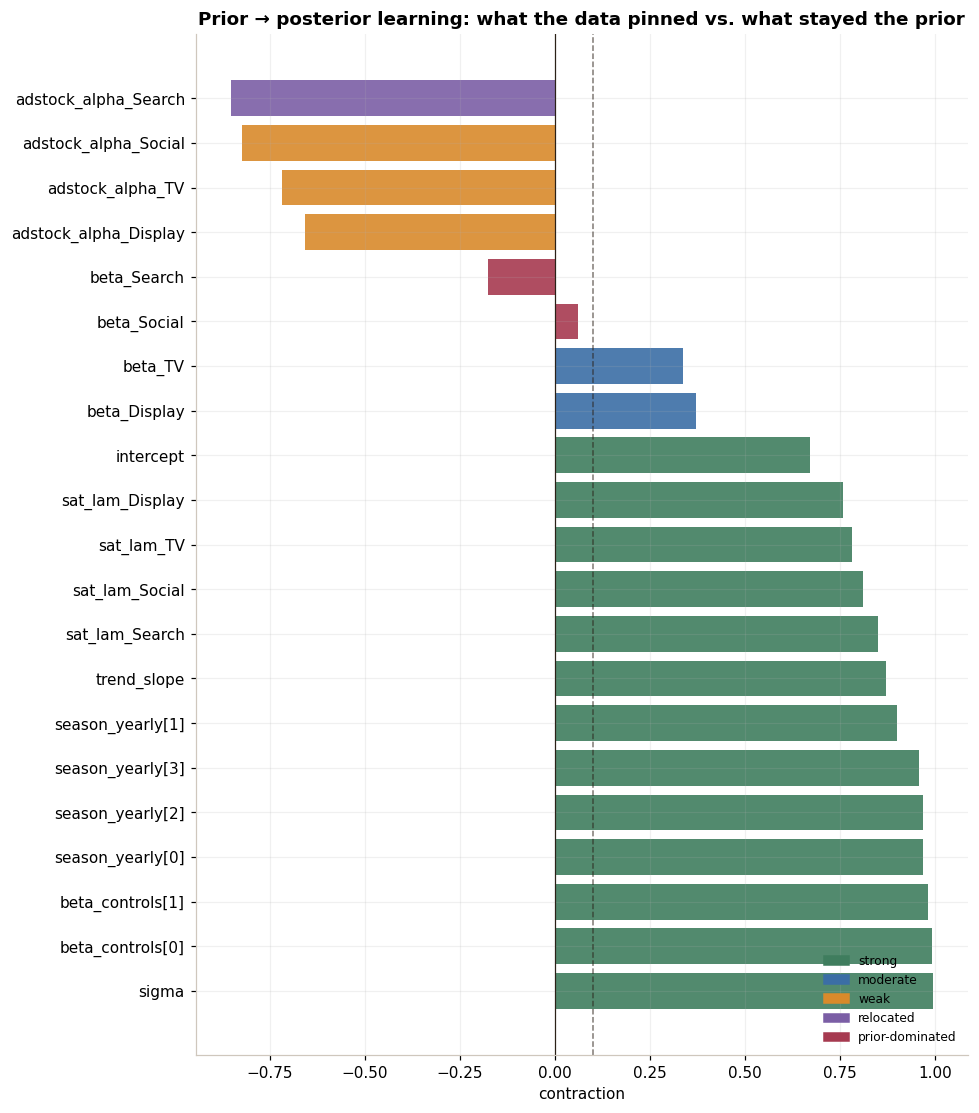

In [24]:
ax = plot_parameter_learning(lrn, threshold=0.1)
ax.figure.set_size_inches(9, 0.42 * len(lrn) + 1.4)
ax.set_title("Prior → posterior learning: what the data pinned vs. what stayed the prior")
plt.tight_layout(); plt.show()

One row deserves a special call-out: **`beta_Search` has a *negative* contraction** — its posterior is
**wider** than its prior, with `shift_z` pushed away from the prior mean. This is the
**demand-confounded** channel the single-equation model cannot pin: Search spend *chases* latent
category demand (the back-door this model only partly closes), so the likelihood pulls $\beta_{\text{Search}}$
in a direction the prior resists, inflating its variance. A negative contraction is a genuine
**prior-data-tension** flag — the diagnostic surfacing identification trouble that a forest plot alone
would hide.

Finally, *see* a parameter the data cannot pin down. We overlay the prior and posterior sample
histograms for `adstock_alpha_TV`. Under the parametric default the story is **prior–data tension**,
not prior-domination: the $\mathrm{Beta}(1,3)$ prior commits to short memory (mean $0.25$), the data
argue for longer carryover, and the posterior comes out *wider* than the prior — measured contraction
is **negative** for every channel's $\alpha_c$ on this world, with substantial overlap (verdict
"weak"). A negative contraction means the likelihood is fighting the prior without winning: the
carryover is only weakly identified, the equifinality catch from `math_01` showing up in the
diagnostic. (Contrast this with what the same overlay would look like for the `MultivariateMMM`
cannibalization $\psi$: despite its one-sided prior, the *data* there narrows the posterior by
hundreds of times — contraction $\approx 1$, overlap $\approx 0.04$ — so that cross-effect is
genuinely **identified**. The diagnostic is precisely what lets you *say which case you are in*
instead of assuming.)

Sampling: [adstock_alpha_Display, adstock_alpha_Search, adstock_alpha_Social, adstock_alpha_TV, beta_Display, beta_Search, beta_Social, beta_TV, beta_controls, intercept, sat_lam_Display, sat_lam_Search, sat_lam_Social, sat_lam_TV, season_yearly, sigma, trend_slope, y_obs]


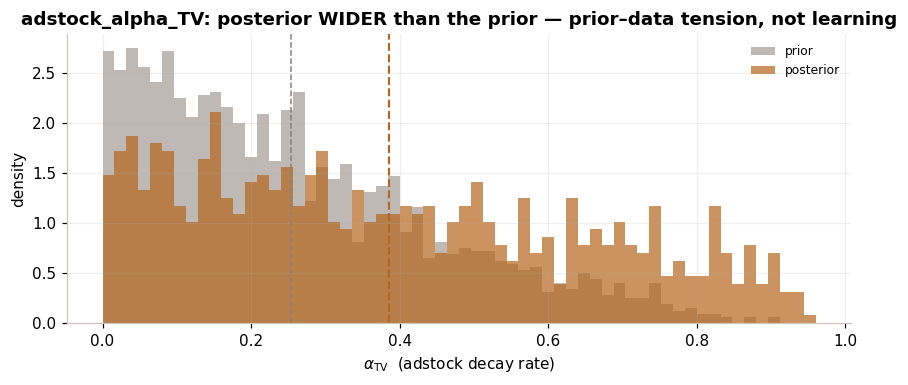

In [25]:
# Fresh prior draws (do not clobber prior_idata from §2). The posterior idata is mmm._trace.
prior = mmm.sample_prior_predictive(samples=2000)

ax = plot_prior_posterior_overlay(prior, mmm._trace, "adstock_alpha_TV")
ax.set_xlabel(r"$\alpha_{\mathrm{TV}}$  (adstock decay rate)")
ax.set_title("adstock_alpha_TV: posterior WIDER than the prior — prior–data tension, not learning")
plt.tight_layout(); plt.show()

In [26]:
# VERIFY (8): the learning diagnostic behaves as the math says. DIRECTIONAL + seeded fit
# (note: the *prior* draw inside compute_parameter_learning is unseeded, so contraction/
# overlap wobble run-to-run -- the checks are inequalities/ORs, never exact values).
expected_cols = {"parameter", "prior_mean", "prior_sd", "post_mean", "post_sd",
                 "contraction", "overlap", "shift_z", "verdict"}
assert expected_cols.issubset(lrn.columns), f"missing columns: {expected_cols - set(lrn.columns)}"

# (a) the adstock_alpha_<CH> decay rates are NOT cleanly learned under the parametric
#     default: measured contraction is NEGATIVE (posterior wider than the short-memory
#     Beta(1,3) prior) with the posterior mean pushed UP for every channel -- the data
#     argue for longer carryover than the prior allows. Where that push exceeds one
#     prior-sd (Search, shift_z ~ +1.6) the verdict is "relocated": the EVIDENCE
#     dominated the location, and the width reflects likelihood flatness (and possibly
#     tail inflation -- see contraction_robust / post_ess_bulk), not a failure to learn.
#     The remaining channels sit below the relocation threshold: verdict "weak".
#     Checks are generous to absorb the unseeded prior draw's wobble.
adstock_rows = lrn[lrn["parameter"].str.startswith("adstock_alpha_")]
assert len(adstock_rows) >= 1, "expected adstock_alpha_<CH> rows in the frame"
assert (adstock_rows["contraction"] < 0.3).all(), \
    f"expected non-narrowing adstock decays; got\n{adstock_rows[['parameter','contraction','shift_z','verdict']]}"
assert (adstock_rows["shift_z"] > 0).all(), \
    "every adstock decay should shift UP (data wants longer carryover than the prior)"
assert adstock_rows["verdict"].isin(["weak", "relocated", "prior-dominated"]).all(), \
    f"unexpected adstock verdicts:\n{adstock_rows[['parameter','contraction','shift_z','verdict']]}"

# (b) sigma and intercept are clearly LEARNED: contraction > 0.5 (huge margin, ~0.99/~0.82).
g = lrn.set_index("parameter")
assert g.loc["sigma", "contraction"] > 0.5,     f"sigma not learned: c={g.loc['sigma','contraction']:.3f}"
assert g.loc["intercept", "contraction"] > 0.5, f"intercept not learned: c={g.loc['intercept','contraction']:.3f}"

print("✓ learning frame has all documented columns:", sorted(expected_cols))
for _, r in adstock_rows.iterrows():
    print(f"✓ {r['verdict'].upper():<9} {r['parameter']:<22} contraction={r['contraction']:+.3f}  "
          f"robust={r['contraction_robust']:+.3f}  shift_z={r['shift_z']:+.2f}  "
          f"overlap={r['overlap']:.3f}")
print(f"✓ LEARNED          {'sigma':<14} contraction={g.loc['sigma','contraction']:+.3f}  "
      f"overlap={g.loc['sigma','overlap']:.3f}")
print(f"✓ LEARNED          {'intercept':<14} contraction={g.loc['intercept','contraction']:+.3f}  "
      f"overlap={g.loc['intercept','overlap']:.3f}")
# beta_Search is a PRINT (a prior-data-tension callout), not a gate -- show its live value.
if "beta_Search" in g.index:
    bs = g.loc["beta_Search"]
    flag = "  <-- posterior WIDER than prior (prior-data tension)" if bs["contraction"] < 0 else ""
    print(f"  note: beta_Search   contraction={bs['contraction']:+.3f}  "
          f"shift_z={bs['shift_z']:+.3f}{flag}")

✓ learning frame has all documented columns: ['contraction', 'overlap', 'parameter', 'post_mean', 'post_sd', 'prior_mean', 'prior_sd', 'shift_z', 'verdict']
✓ RELOCATED adstock_alpha_Search   contraction=-0.853  robust=-1.630  shift_z=+1.50  overlap=0.494
✓ WEAK      adstock_alpha_Social   contraction=-0.823  robust=-1.947  shift_z=+0.83  overlap=0.698
✓ WEAK      adstock_alpha_TV       contraction=-0.719  robust=-1.143  shift_z=+0.66  overlap=0.768
✓ WEAK      adstock_alpha_Display  contraction=-0.657  robust=-1.162  shift_z=+0.63  overlap=0.752
✓ LEARNED          sigma          contraction=+0.995  overlap=0.147
✓ LEARNED          intercept      contraction=+0.672  overlap=0.019
  note: beta_Search   contraction=-0.177  shift_z=+0.128  <-- posterior WIDER than prior (prior-data tension)


## Recap & what's next

**The model, end to end.** We standardized the KPI, summed an interpretable linear predictor $\mu_t$
(baseline + media + controls), pushed media spend through the framework's *exponential* saturation
$1-e^{-\lambda u}$ and its *blend-of-two-geometric-adstocks*, and put a Gaussian likelihood on
$\tilde y_t \sim \mathcal N(\mu_t,\sigma)$.

**Inference.** Bayes' theorem turns prior $\times$ likelihood into a posterior we can only *sample*;
**NUTS** does that with gradient-guided, no-U-turn Hamiltonian dynamics. We confirmed convergence
($\hat R \approx 1$, healthy ESS), then read the posterior as forests, ROI bands, a posterior-predictive
fit ($\text{corr} > 0.7$), and a component decomposition.

**The honest result.** The fit is *good in-sample* yet the recovered **ROAS is biased** versus Aurora's
known truth — TV/Display act through an unmodeled **awareness mediator**, and Search/Social spend
**chases latent demand**. The Bayesian machinery quantified our uncertainty perfectly; it cannot conjure
identification that the data + single-equation structure do not contain.

**Did the data teach us?** §8 added the honest sanity check a forest plot cannot give:
`compute_parameter_learning()` measured **prior-to-posterior contraction / overlap / shift** per
parameter. The intercept, controls and $\sigma$ were *strongly learned*; the
`adstock_alpha_<CH>` decay rates showed **negative contraction** with high overlap (verdict *weak*) —
the short-memory $\mathrm{Beta}(1,3)$ prior in tension with data that wants longer carryover, the
posterior widening rather than narrowing: observational data barely identifies carryover, the
equifinality theme made quantitative. `beta_Search` told the same tension story on the
demand-confounded channel. The lesson generalizes: a one-sided prior makes
$P(\psi<0)\approx 1$ vacuous, so always ask *contraction/overlap*, not *sign*.

**Two things to keep straight here:**
1. The core saturation is **$1-e^{-\lambda u}$**, not a Hill curve. The default
   `adstock_alpha_<CH>` (since June 2026) **is** a real decay rate; on the legacy path,
   `adstock_<CH>` is a **$\mathrm{Beta}(2,2)$ blend weight**, not a decay rate (see `math_01`).
2. `compute_component_decomposition()` is **additive** to `predict()` — baseline (intercept + trend +
   seasonality + controls) plus the per-channel media stack reconstructs the fitted line (we verified
   $\mathrm{corr}\approx 1$ in §7). Read the mean-zero pieces (Fourier seasonality, centered controls) as
   *amplitude around the level*, not contributions to the average.

**Next in the math series:**
- **`math_05_calibration.ipynb`** — fold a geo-lift experiment into the likelihood to **pin $\beta_c$**,
  break the equifinality, and *de-bias* the ROAS we just saw be wrong.